<a href="https://colab.research.google.com/github/sebaannkuruvilla/AutomatedEquivalenceTesting/blob/main/Part1_GraphGenerator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Weighted Directed Graph
* Create a weighted directed graph
* Input: Node Range, Weight Range
* Output: Weighted Directed Graph  [Format: Dict of Dicts]
* Display of Graph (* Using Networkx)

In [1]:
import random
import copy
import numpy as np
import pprint
import networkx as nx
import matplotlib.pyplot as plt


In [2]:
#creates node and sample degrees
def node_creation(node_range):
    order=random.randint(node_range[0], node_range[1])#order(G)= random number from range of vertices
    node_list=list(range(0, order))   #node_list= 0 ... order(G)-1
    degree_list=[random.randint(0, order-1) for i in range(order)] #degree for each vertex sampled from range(0,order(G)-1)
    return node_list,degree_list

In [3]:
def edge_creation(node_list,degree_list):
    graph={}
    temp_nodes=copy.deepcopy(node_list)
    for node,degree in zip(node_list,degree_list):
        temp_nodes.remove(node)
        temp_array = np.array(temp_nodes)
        graph[node]=np.random.choice(temp_array, size=degree, replace=False).tolist()
        temp_nodes=temp_array.tolist()
        temp_nodes.append(node)
    return graph

In [4]:
def assign_weight(graph,weight_range):
    graph_w={}
    tuple_list=[]
    for node, nbors in graph.items():
        graph_w[node]={}
        for nb in nbors:
            graph_w[node][nb]=random.randint(weight_range[0],weight_range[1])
            tuple_list.append((node,nb,graph_w[node][nb] ))
    return  graph_w,tuple_list

In [5]:
def create_weighted_directed_graph(node_range,weight_range):
    node_list,degree_list=node_creation(node_range)
    g1=edge_creation(node_list,degree_list)
    g2=assign_weight(g1,weight_range)
    del g1

    return g2

In [6]:

def display_graph(dgraph,wtuple):
    G = nx.DiGraph()
    G.add_nodes_from(list(dgraph.keys()))
    G.add_weighted_edges_from(wtuple)
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='cornflowerblue',node_size=300, arrowsize=5,edge_color='slategrey')
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.show()



The graph is: 
{0: {1: 33, 2: 8, 3: 14, 4: 46},
 1: {2: 33, 3: 28, 4: 29},
 2: {0: 19, 1: 29, 3: 24},
 3: {0: 21, 1: 18, 2: 44},
 4: {0: 37, 1: 11, 2: 15, 3: 35}}


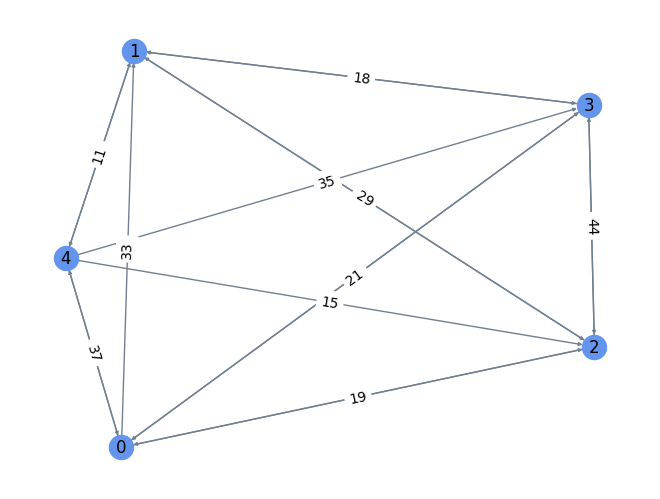

In [7]:
node_range=(1,5)
weight_range=(5,50)
test_graph,test_tuple=create_weighted_directed_graph(node_range,weight_range)
print("The graph is: ")
pprint.pprint(test_graph)
display_graph(test_graph,test_tuple)

The graph is: 
{0: {2: 13, 4: 12}, 1: {3: 27, 4: 39}, 2: {3: 37}, 3: {2: 49}, 4: {0: 5, 1: 15}}


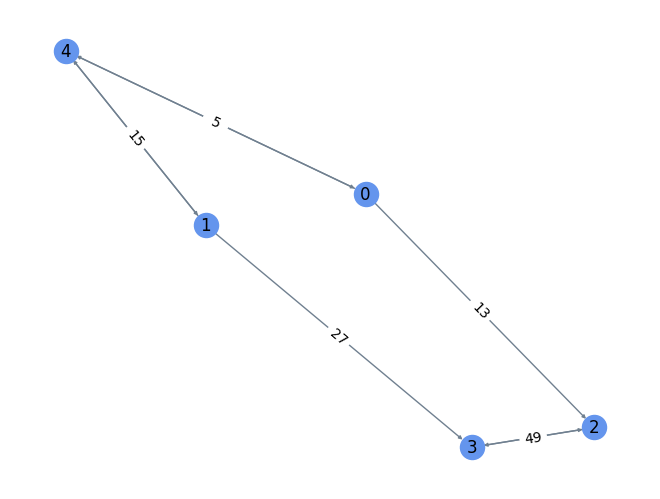

In [8]:
node_range=(1,5)
weight_range=(5,50)
test_graph,test_tuple=create_weighted_directed_graph(node_range,weight_range)
print("The graph is: ")
pprint.pprint(test_graph)
display_graph(test_graph,test_tuple)